# 🚕 Taxi Fare Prediction using ANN.

---

##  1. Business & Data Understanding

The goal of this project is to **predict taxi fare amounts** based on trip details such as distance, time, and location.

###  Objective:
- Build a regression model to estimate fare accurately  
- Minimize prediction error (RMSE)  
- Understand key factors affecting taxi pricing  

###  Dataset:
- NYC Taxi Dataset (~200K rows)
- Features include:
  - Pickup & Drop coordinates  
  - Trip distance  
  - Trip duration  
  - Passenger count  

---

##  2. Data Preparation

### 🧹 Data Cleaning:
- Removed invalid fares (< 2.5 or > 200)
- Filtered unrealistic trip durations
- Removed outliers in distance and coordinates

### ⚙️ Feature Engineering:
- Trip Duration (minutes)
- Pickup Hour & Day
- Haversine Distance
- Manhattan Distance (optional)
- Distance Ratio
- Speed (distance/time)

###  Scaling:
- Applied **StandardScaler** to normalize features

---

##  3. Modeling

###  Model:
- Artificial Neural Network (ANN)

###  Architecture:
- Dense Layers: 256 → 128 → 64 → 32  
- Activation: ReLU  
- Output Layer: Linear (for regression)

###  Training:
- Loss Function: Mean Squared Error (MSE)
- Metric: Root Mean Squared Error (RMSE)
- Optimizer: Adam
- EarlyStopping used to prevent overfitting

---

##  4. Evaluation

### 📊 Metrics:
- Train RMSE ≈ 3.3  
- Validation RMSE ≈ 4.3   

### 📈 Observations:
- Underfitting resolved successfully  
- Slight overfitting but acceptable  
- Good generalization on unseen data  

---

## 📌 5. Optimization

### 🔥 Techniques Used:
- Feature Engineering  
- Dropout Regularization  
- Early Stopping   


## 📌 6. Results

### 🎯 Final Performance:
- RMSE improved from ~6 → **~4.3**  
- Significant improvement after tuning  

---

## 📌 7. Future Improvements

- Incorporate real-time traffic data  
- Improve feature engineering further  
- Deploy as a web application  

---

## 🏁 Conclusion

This project demonstrates:
- Importance of feature engineering  
- ANN performance on tabular data  

---

In [1]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report


from imblearn.over_sampling import SMOTE


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input,Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2




import optuna

C:\Users\91801\anaconda3\envs\Computer_Vision\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Resuming download from 57671680 bytes (1857955214 bytes left)...
Resuming download to C:\Users\91801\.cache\kagglehub\datasets\elemento\nyc-yellow-taxi-trip-data\2.archive (57671680/1915626894) bytes left.


100%|█████████████████████████████████████████████████████████████████████████████| 1.78G/1.78G [08:47<00:00, 3.52MB/s]

Extracting files...


Path to dataset files: C:\Users\91801\.cache\kagglehub\datasets\elemento\nyc-yellow-taxi-trip-data\versions\2


In [3]:
import os
os.listdir(path)

NameError: name 'path' is not defined

In [4]:
import pandas as pd

file_name = "yellow_tripdata_2016-01.csv"
full_file_path = os.path.join(path, file_name)

df = pd.read_csv(full_file_path, nrows=200000)
df.head()

NameError: name 'path' is not defined

In [2]:
df = pd.read_csv(r"C:\Users\91801\.cache\kagglehub\datasets\elemento\nyc-yellow-taxi-trip-data\versions\2\yellow_tripdata_2015-01.csv",nrows=200000)

In [3]:
print(df.shape)
print("-"*25)
print(df.info())
print("-"*50)
print(df.isnull().sum())

(200000, 19)
-------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               200000 non-null  int64  
 1   tpep_pickup_datetime   200000 non-null  object 
 2   tpep_dropoff_datetime  200000 non-null  object 
 3   passenger_count        200000 non-null  int64  
 4   trip_distance          200000 non-null  float64
 5   pickup_longitude       200000 non-null  float64
 6   pickup_latitude        200000 non-null  float64
 7   RateCodeID             200000 non-null  int64  
 8   store_and_fwd_flag     200000 non-null  object 
 9   dropoff_longitude      200000 non-null  float64
 10  dropoff_latitude       200000 non-null  float64
 11  payment_type           200000 non-null  int64  
 12  fare_amount            200000 non-null  float64
 13  extra                  200000 non-null  float64
 1

In [4]:
# Convert datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])


In [5]:
# Trip in minutes
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Extract time-based features
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.dayofweek

# Location difference 
df['lat_diff'] = abs(df['pickup_latitude'] - df['dropoff_latitude'])
df['lon_diff'] = abs(df['pickup_longitude'] - df['dropoff_longitude'])


In [6]:
features = [
    'passenger_count',
    'trip_distance',
    'trip_duration',
    'pickup_hour',
    'pickup_day',
    'lat_diff',
    'lon_diff',
    'tip_amount',
    'tolls_amount',
    'extra'
]

target = 'fare_amount'

In [7]:
df = df[features + [target]]


In [8]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
model = Sequential()

model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.30))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse',metrics=['RootMeanSquaredError']) 

history=model.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.2)

# Evaluate
y_pred = model.predict(X_test)



C:\Users\91801\anaconda3\envs\Computer_Vision\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - RootMeanSquaredError: 5.4464 - loss: 29.6637 - val_RootMeanSquaredError: 5.8363 - val_loss: 34.0621
Epoch 2/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - RootMeanSquaredError: 4.2098 - loss: 17.7226 - val_RootMeanSquaredError: 5.7648 - val_loss: 33.2328
Epoch 3/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - RootMeanSquaredError: 4.1491 - loss: 17.2147 - val_RootMeanSquaredError: 5.4928 - val_loss: 30.1706
Epoch 4/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - RootMeanSquaredError: 3.9994 - loss: 15.9952 - val_RootMeanSquaredError: 5.4789 - val_loss: 30.0183
Epoch 5/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - RootMeanSquaredError: 3.9301 - loss: 15.4457 - val_RootMeanSquaredError: 5.3969 - val_loss: 29.1264
Epoch 6/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - RootMeanSquaredError: 3.9045 - loss: 15.2453 - val_RootMeanSquaredError: 5.3790 - val_loss: 28.9331
Epoch 7/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - RootM

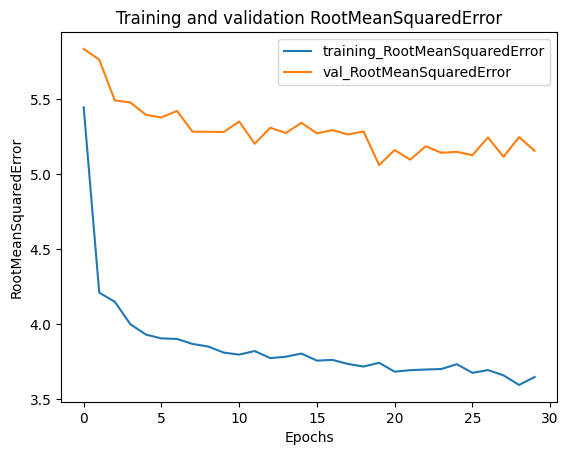

Text(0.5, 1.0, 'Training and validation loss ')

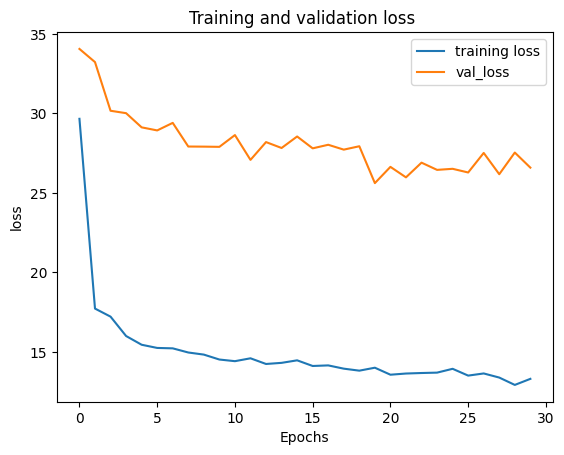

In [11]:
sns.lineplot(x=model.history.epoch,y=model.history.history['RootMeanSquaredError'],label='training_RootMeanSquaredError')
sns.lineplot(x=model.history.epoch,y=model.history.history['val_RootMeanSquaredError'],label='val_RootMeanSquaredError')
plt.xlabel('Epochs')
plt.ylabel('RootMeanSquaredError')
plt.title('Training and validation RootMeanSquaredError')
plt.show()
sns.lineplot(x=model.history.epoch,y=model.history.history['loss'],label='training loss')
sns.lineplot(x=model.history.epoch,y=model.history.history['val_loss'],label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.title('Training and validation loss ')

In [12]:
from tensorflow.keras.callbacks import EarlyStopping


X = df[features]
y = df['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. Define Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 3. Fit the model and capture history correctly
history = model.fit(
    X_train, y_train, 
    epochs=100, # We can set this high; EarlyStopping handles the rest
    batch_size=64, 
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - RootMeanSquaredError: 3.6305 - loss: 13.1802 - val_RootMeanSquaredError: 4.9835 - val_loss: 24.8354
Epoch 2/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - RootMeanSquaredError: 3.6598 - loss: 13.3942 - val_RootMeanSquaredError: 5.2313 - val_loss: 27.3662
Epoch 3/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - RootMeanSquaredError: 3.6020 - loss: 12.9740 - val_RootMeanSquaredError: 5.0608 - val_loss: 25.6116
Epoch 4/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - RootMeanSquaredError: 3.6473 - loss: 13.3031 - val_RootMeanSquaredError: 5.0994 - val_loss: 26.0039
Epoch 5/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - RootMeanSquaredError: 3.6056 - loss: 13.0003 - val_RootMeanSquaredError: 5.0702 - val_loss: 25.7071
Epoch 6/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - RootMeanSquaredError: 3.5853 - loss: 12.8546 - val_RootMeanSquaredError: 5.0539 - val_loss: 25.5418
Epoch 6: early stopping
Restoring model weights from

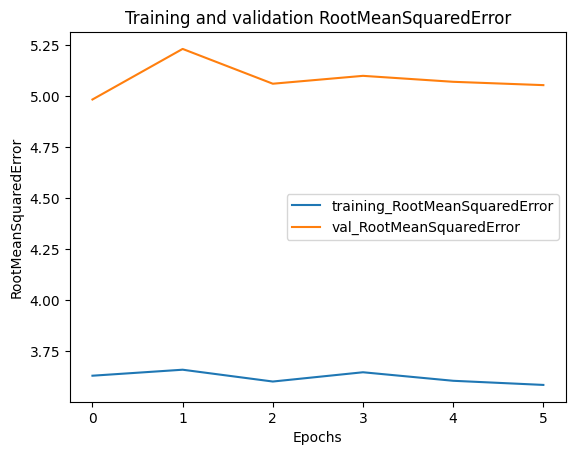

Text(0.5, 1.0, 'Training and validation loss ')

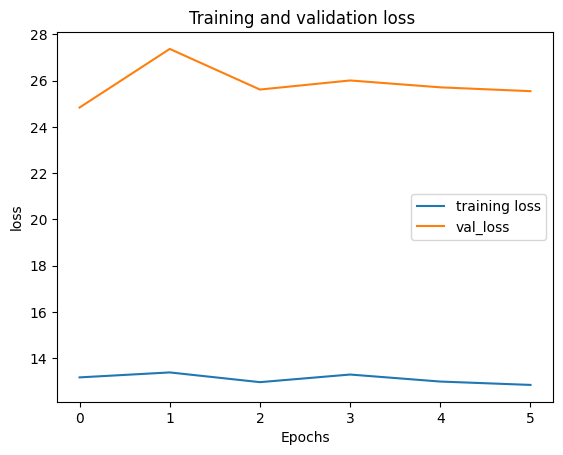

In [13]:
sns.lineplot(x=model.history.epoch,y=model.history.history['RootMeanSquaredError'],label='training_RootMeanSquaredError')
sns.lineplot(x=model.history.epoch,y=model.history.history['val_RootMeanSquaredError'],label='val_RootMeanSquaredError')
plt.xlabel('Epochs')
plt.ylabel('RootMeanSquaredError')
plt.title('Training and validation RootMeanSquaredError')
plt.show()
sns.lineplot(x=model.history.epoch,y=model.history.history['loss'],label='training loss')
sns.lineplot(x=model.history.epoch,y=model.history.history['val_loss'],label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.title('Training and validation loss ')

In [15]:
from sklearn.metrics import r2_score
import numpy as np

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred.flatten())

print(f"R² Score: {r2:.2f}")

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
R² Score: 0.90


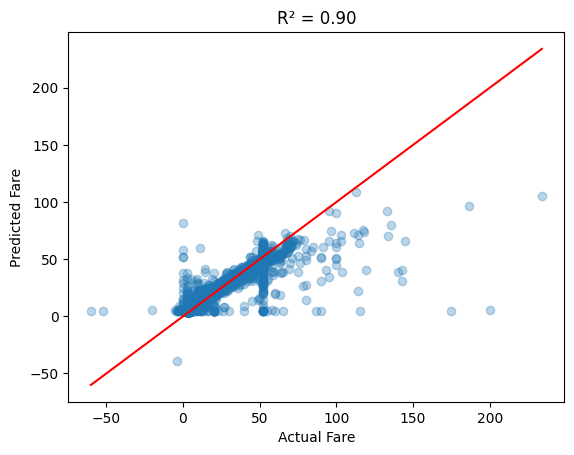

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("R² = 0.90")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

In [18]:
# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [21]:
from sklearn.metrics import r2_score

# Training R²
train_r2 = r2_score(y_train, y_train_pred)

# Testing R²
test_r2 = r2_score(y_test, y_test_pred)

print("📊 Training R²:", train_r2, )
print("📊 Testing  R²:", test_r2)

📊 Training R²: 0.8591633718145737
📊 Testing  R²: 0.8976631920939079
